**Install and imports**

In [1]:
!pip install -q xgboost streamlit==1.32.0


In [2]:
#!pip install xgboost streamlit==1.32.0 scikit-learn pandas numpy matplotlib seaborn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score,
    recall_score, f1_score, matthews_corrcoef,
    confusion_matrix, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import joblib
import os


**Load dataset (HR Analytics: Job Change of Data Scientists)**

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
csv_path = "/content/drive/MyDrive/ML-Dataset2/Diabetes.csv"  # update folder/name
df = pd.read_csv(csv_path)

print(df.shape)
df.head()


(1000, 14)


,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


**Basic EDA and cleaning**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   object 
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   object 
dtypes: float64(8), int64(4), object(2)
memory usage: 109.5+ KB


In [6]:
print(df.describe().T)

# Check missing values
print ("\n checking missing values \n")
print(df.isna().sum())

            count           mean           std    min       25%      50%  \
ID         1000.0     340.500000  2.403977e+02    1.0    125.75    300.5   
No_Pation  1000.0  270551.408000  3.380758e+06  123.0  24063.75  34395.5   
AGE        1000.0      53.528000  8.799241e+00   20.0     51.00     55.0   
Urea       1000.0       5.124743  2.935165e+00    0.5      3.70      4.6   
Cr         1000.0      68.943000  5.998475e+01    6.0     48.00     60.0   
HbA1c      1000.0       8.281160  2.534003e+00    0.9      6.50      8.0   
Chol       1000.0       4.862820  1.301738e+00    0.0      4.00      4.8   
TG         1000.0       2.349610  1.401176e+00    0.3      1.50      2.0   
HDL        1000.0       1.204750  6.604136e-01    0.2      0.90      1.1   
LDL        1000.0       2.609790  1.115102e+00    0.3      1.80      2.5   
VLDL       1000.0       1.854700  3.663599e+00    0.1      0.70      0.9   
BMI        1000.0      29.578020  4.962388e+00   19.0     26.00     30.0   

           

In [7]:

# Simple handling: drop rows with NA (or impute as you wish)
df = df.dropna()

# Check missing values
print ("\n checking missing values \n")
print(df.isna().sum())

# If target column has a different name, change here
#target_col = 'CLASS'   # e.g. 'stroke' or 'Outcome'
##X = df.drop(columns=[target_col])
#y = df[target_col].astype(str).str.strip().str.upper()  # Y / N / P cleaned
#y = df[target_col]

target_col = "CLASS"

X = df.drop(columns=[target_col])

# Clean string labels
y_str = df[target_col].astype(str).str.strip().str.upper()

# Map to integers for models like XGBoost
label_map = {"N": 0, "P": 1, "Y": 2}
y = y_str.map(label_map)

print(y.value_counts())      # check counts
classes = sorted(y.unique()) # [0,1,2]


# For any categorical columns, one‑hot encode
X = pd.get_dummies(X, drop_first=True)

# Clean feature names for XGBoost
X.columns = X.columns.astype(str)
X.columns = X.columns.str.replace(r"[\[\]<]", "_", regex=True)

print(X.shape, y.shape)



 checking missing values 

ID           0
No_Pation    0
Gender       0
AGE          0
Urea         0
Cr           0
HbA1c        0
Chol         0
TG           0
HDL          0
LDL          0
VLDL         0
BMI          0
CLASS        0
dtype: int64
CLASS
2    844
0    103
1     53
Name: count, dtype: int64
(1000, 14) (1000,)


In [8]:
# Strip leading/trailing spaces and convert to uppercase
df['CLASS'] = df['CLASS'].str.strip().str.upper()

In [9]:
print(df['CLASS'].unique())         # should now be ['N', 'P', 'Y']
print(df['CLASS'].value_counts())   # accurate counts for each class

['N' 'P' 'Y']
CLASS
Y    844
N    103
P     53
Name: count, dtype: int64


Visualization of Dataset Distribution

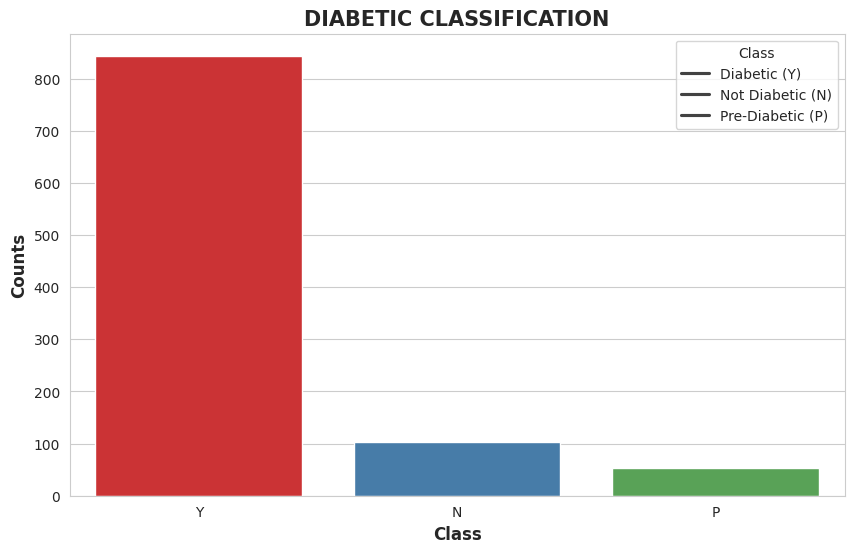

In [10]:
classifi_diabetic=df["CLASS"].value_counts().reset_index()
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")
sns.barplot(data=classifi_diabetic,x="CLASS",y="count",hue="CLASS",palette="Set1")
plt.xlabel("Class",fontweight="bold",fontsize=12)
plt.ylabel("Counts",fontweight="bold",fontsize=12)
plt.title("DIABETIC CLASSIFICATION",fontweight="bold",fontsize=15)
plt.legend(
    title="Class",
    labels=["Diabetic (Y)", "Not Diabetic (N)", "Pre-Diabetic (P)"]
)
plt.show()



In [11]:
# Ensure labels are clean strings without extra spaces or casing differences
y = y.astype(str).str.strip().str.upper()

# Check counts again
class_counts = y.value_counts()
print(class_counts)


CLASS
2    844
0    103
1     53
Name: count, dtype: int64


** Train‑test split and scaling**

In [12]:
# Check class counts
class_counts = y.value_counts()
print(class_counts)

# Keep only classes with at least 2 samples
valid_classes = class_counts[class_counts >= 2].index
mask = y.isin(valid_classes)
X_filtered = X[mask].copy()
y_filtered = y[mask].copy()

# Now safe to stratify
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered,
    test_size=0.2,
    random_state=42,
    stratify=y_filtered
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

classes = sorted(y.unique())  # ['N','P','Y'] typically

CLASS
2    844
0    103
1     53
Name: count, dtype: int64


In [13]:
# create test CSV for Streamlit upload
target_col = "CLASS"   # or your actual target column name

test_df = X_test.copy()
test_df[target_col] = y_test.values
test_df.to_csv("test_data.csv", index=False)


**Helper: metric computation**

In [16]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, average_precision_score
)
from sklearn.preprocessing import label_binarize
import numpy as np

classes = [0, 1, 2]   # global

def compute_metrics(model_name, y_true, y_pred, y_proba=None):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)

    auc = np.nan
    if y_proba is not None:
        try:
            y_true_bin = label_binarize(y_true, classes=classes)  # (n_samples, 3)
            # y_proba must also be (n_samples, 3)
            auc = average_precision_score(
                y_true_bin, y_proba, average="macro"
            )
        except Exception:
            auc = np.nan

    return {
        "ML Model Name": model_name,
        "Accuracy": acc,
        "AUC": auc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "MCC": mcc,
    }


In [55]:
'''from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score,
    recall_score, f1_score, matthews_corrcoef
)
from sklearn.preprocessing import label_binarize
from sklearn.exceptions import UndefinedMetricWarning
import numpy as np
import warnings

# classes = [0, 1, 2]  # defined earlier from y.unique()

def compute_metrics(model_name, y_true, y_pred, y_proba=None):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)

    auc = np.nan
    if y_proba is not None:
        try:
            y_true_bin = label_binarize(y_true, classes=classes)
            with warnings.catch_warnings():
                warnings.filterwarnings(
                    "ignore",
                    category=UndefinedMetricWarning
                )
                auc = roc_auc_score(
                    y_true_bin,
                    y_proba,
                    average="macro",
                    multi_class="ovr"
                )
        except Exception:
            auc = np.nan

    return {
        "ML Model Name": model_name,
        "Accuracy": acc,
        "AUC": auc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "MCC": mcc,
    }
'''

**Train all 6 models**

In [17]:
results = []
trained_models = {}

# 1. Logistic Regression (multi-class, with class_weight)
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"   # let sklearn choose multi_class automatically
)
log_reg.fit(X_train_scaled, y_train)
y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)          # (n_samples, 3)
results.append(compute_metrics("Logistic Regression", y_test, y_pred, y_proba))
trained_models["Logistic Regression"] = log_reg

# 2. Decision Tree
dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
y_proba = dt.predict_proba(X_test)                      # (n_samples, 3)
results.append(compute_metrics("Decision Tree", y_test, y_pred, y_proba))
trained_models["Decision Tree"] = dt

# 3. k-NN (uses scaled features)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
y_proba = knn.predict_proba(X_test_scaled)              # (n_samples, 3)
results.append(compute_metrics("kNN", y_test, y_pred, y_proba))
trained_models["kNN"] = knn

# 4. Naive Bayes (Gaussian)
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)
y_proba = nb.predict_proba(X_test)                      # (n_samples, 3)
results.append(compute_metrics("Naive Bayes", y_test, y_pred, y_proba))
trained_models["Naive Bayes"] = nb

# 5. Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)                      # (n_samples, 3)
results.append(compute_metrics("Random Forest", y_test, y_pred, y_proba))
trained_models["Random Forest"] = rf

# 6. XGBoost (multi-class with class-based sample weights)
from xgboost import XGBClassifier

y_train_int = y_train.astype(int)
class_counts = y_train_int.value_counts()
class_weight_map = {
    cls: len(y_train_int) / (len(class_counts) * cnt)
    for cls, cnt in class_counts.items()
}
sample_weight = y_train_int.map(class_weight_map).values

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    objective="multi:softprob",
    num_class=len(classes),
    random_state=42
)

xgb.fit(X_train, y_train_int, sample_weight=sample_weight)
y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)                     # (n_samples, 3)
results.append(compute_metrics("XGBoost", y_test, y_pred, y_proba))
trained_models["XGBoost"] = xgb

# Final comparison table
results_df = pd.DataFrame(results)
results_df


,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.935,0.799535,0.772678,0.852475,0.804533,0.784816
1,Decision Tree,0.990,0.950228,0.996101,0.950794,0.972365,0.962918
2,kNN,0.920,0.799771,0.731073,0.696872,0.712932,0.694721
3,Naive Bayes,0.105,0.368722,0.350970,0.355030,0.074242,0.066998
4,Random Forest,0.995,0.996923,0.998039,0.966667,0.981473,0.981577
5,XGBoost,0.995,0.999988,0.998039,0.966667,0.981473,0.981577


**Confusion matrix and classification report for best model**

Best model based on F1: Random Forest
Confusion Matrix:
 [[ 21   0   0]
 [  0   9   1]
 [  0   0 169]]


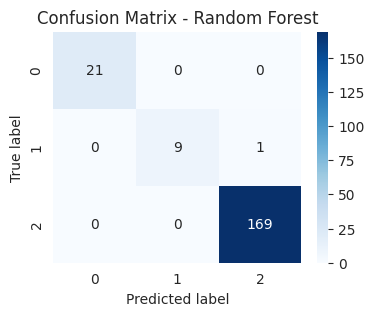


Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        21
           1     1.0000    0.9000    0.9474        10
           2     0.9941    1.0000    0.9971       169

    accuracy                         0.9950       200
   macro avg     0.9980    0.9667    0.9815       200
weighted avg     0.9950    0.9950    0.9949       200



In [18]:
# Pick best model by highest F1
best_row = results_df.sort_values("F1", ascending=False).iloc[0]
best_model_name = best_row["ML Model Name"]
best_model = trained_models[best_model_name]

print(f"Best model based on F1: {best_model_name}")

# Use scaled features for LR and kNN, raw for others
if best_model_name in ["Logistic Regression", "kNN"]:
    X_test_for_best = X_test_scaled
else:
    X_test_for_best = X_test

# Predict
y_pred_best = best_model.predict(X_test_for_best)

# Ensure both true and predicted labels are numeric ints
y_true_int = np.asarray(y_test, dtype=int)
y_pred_int = np.asarray(y_pred_best, dtype=int)

# Confusion matrix
cm = confusion_matrix(y_true_int, y_pred_int)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4, 3))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_true_int, y_pred_int, digits=4))


**Save models for Streamlit**

In [19]:
import joblib
import os

os.makedirs('model', exist_ok=True)

for name, mdl in trained_models.items():
    filename = name.lower().replace(' ', '_') + '.pkl'
    joblib.dump(mdl, f'model/{filename}', compress=3)

joblib.dump(scaler, 'model/scaler.pkl')
joblib.dump(list(X.columns), 'model/feature_columns.pkl')


['model/feature_columns.pkl']